# Differential Privacy

Differential Privacy (DP) is a mathematical privacy framework that ensures the result of an analysis or machine-learning algorithm does not change significantly when one person’s data is added to or removed from the dataset.

Differential privacy protects a person’s information by adding controlled randomness, making it difficult to tell whether that person’s data was used.


In simple words:

> An observer should not be able to confidently determine whether a particular person's data was used.

Formally, an algorithm $M$ provides $(\varepsilon,\delta)$-differential privacy if, for any two neighboring datasets $D$ and $D'$ that differ by one protected record or user:

$$
\Pr[M(D) \in S]
\leq
e^{\varepsilon}\Pr[M(D') \in S] + \delta
$$

where:

- $M$: the randomized algorithm
- $D,D'$: neighboring datasets
- $S$: any possible collection of outputs
- $\varepsilon$: privacy loss; a smaller value generally means stronger privacy
- $\delta$: a small probability of exceeding the main privacy guarantee

In machine learning, differential privacy is commonly implemented by:

1. Limiting each record's or user's influence using **gradient clipping**
2. Adding calibrated random **noise**
3. Tracking accumulated privacy loss with a **privacy accountant**

Differential privacy helps protect against membership inference, training-data extraction, and memorization leakage. However, it creates a **privacy--utility trade-off**: stronger privacy generally requires more noise and may reduce model accuracy.













The information in datasets like healthcare, financial transactions, user preferences, etc., is valuable and has the potential for scientific breakthroughs and provides important business insights. However, such data is also sensitive and there is a risk of compromising individual privacy.

Traditional methods like anonymization alone would not work because of attacks like Re-identification and Data Linkage. That’s where differential privacy comes in. It provides the possibility of analyzing data while ensuring the privacy of individuals.


## Example 

Imagine two datasets that are identical except for a single record (for instance, Alice’s data). Differential Privacy (DP) guarantees that any analysis (M), like calculating the average income, will produce nearly identical results for both datasets (O and O’ would be similar). This preserves group patterns while obscuring individual details, ensuring the individual’s information remains hidden in the crowd.
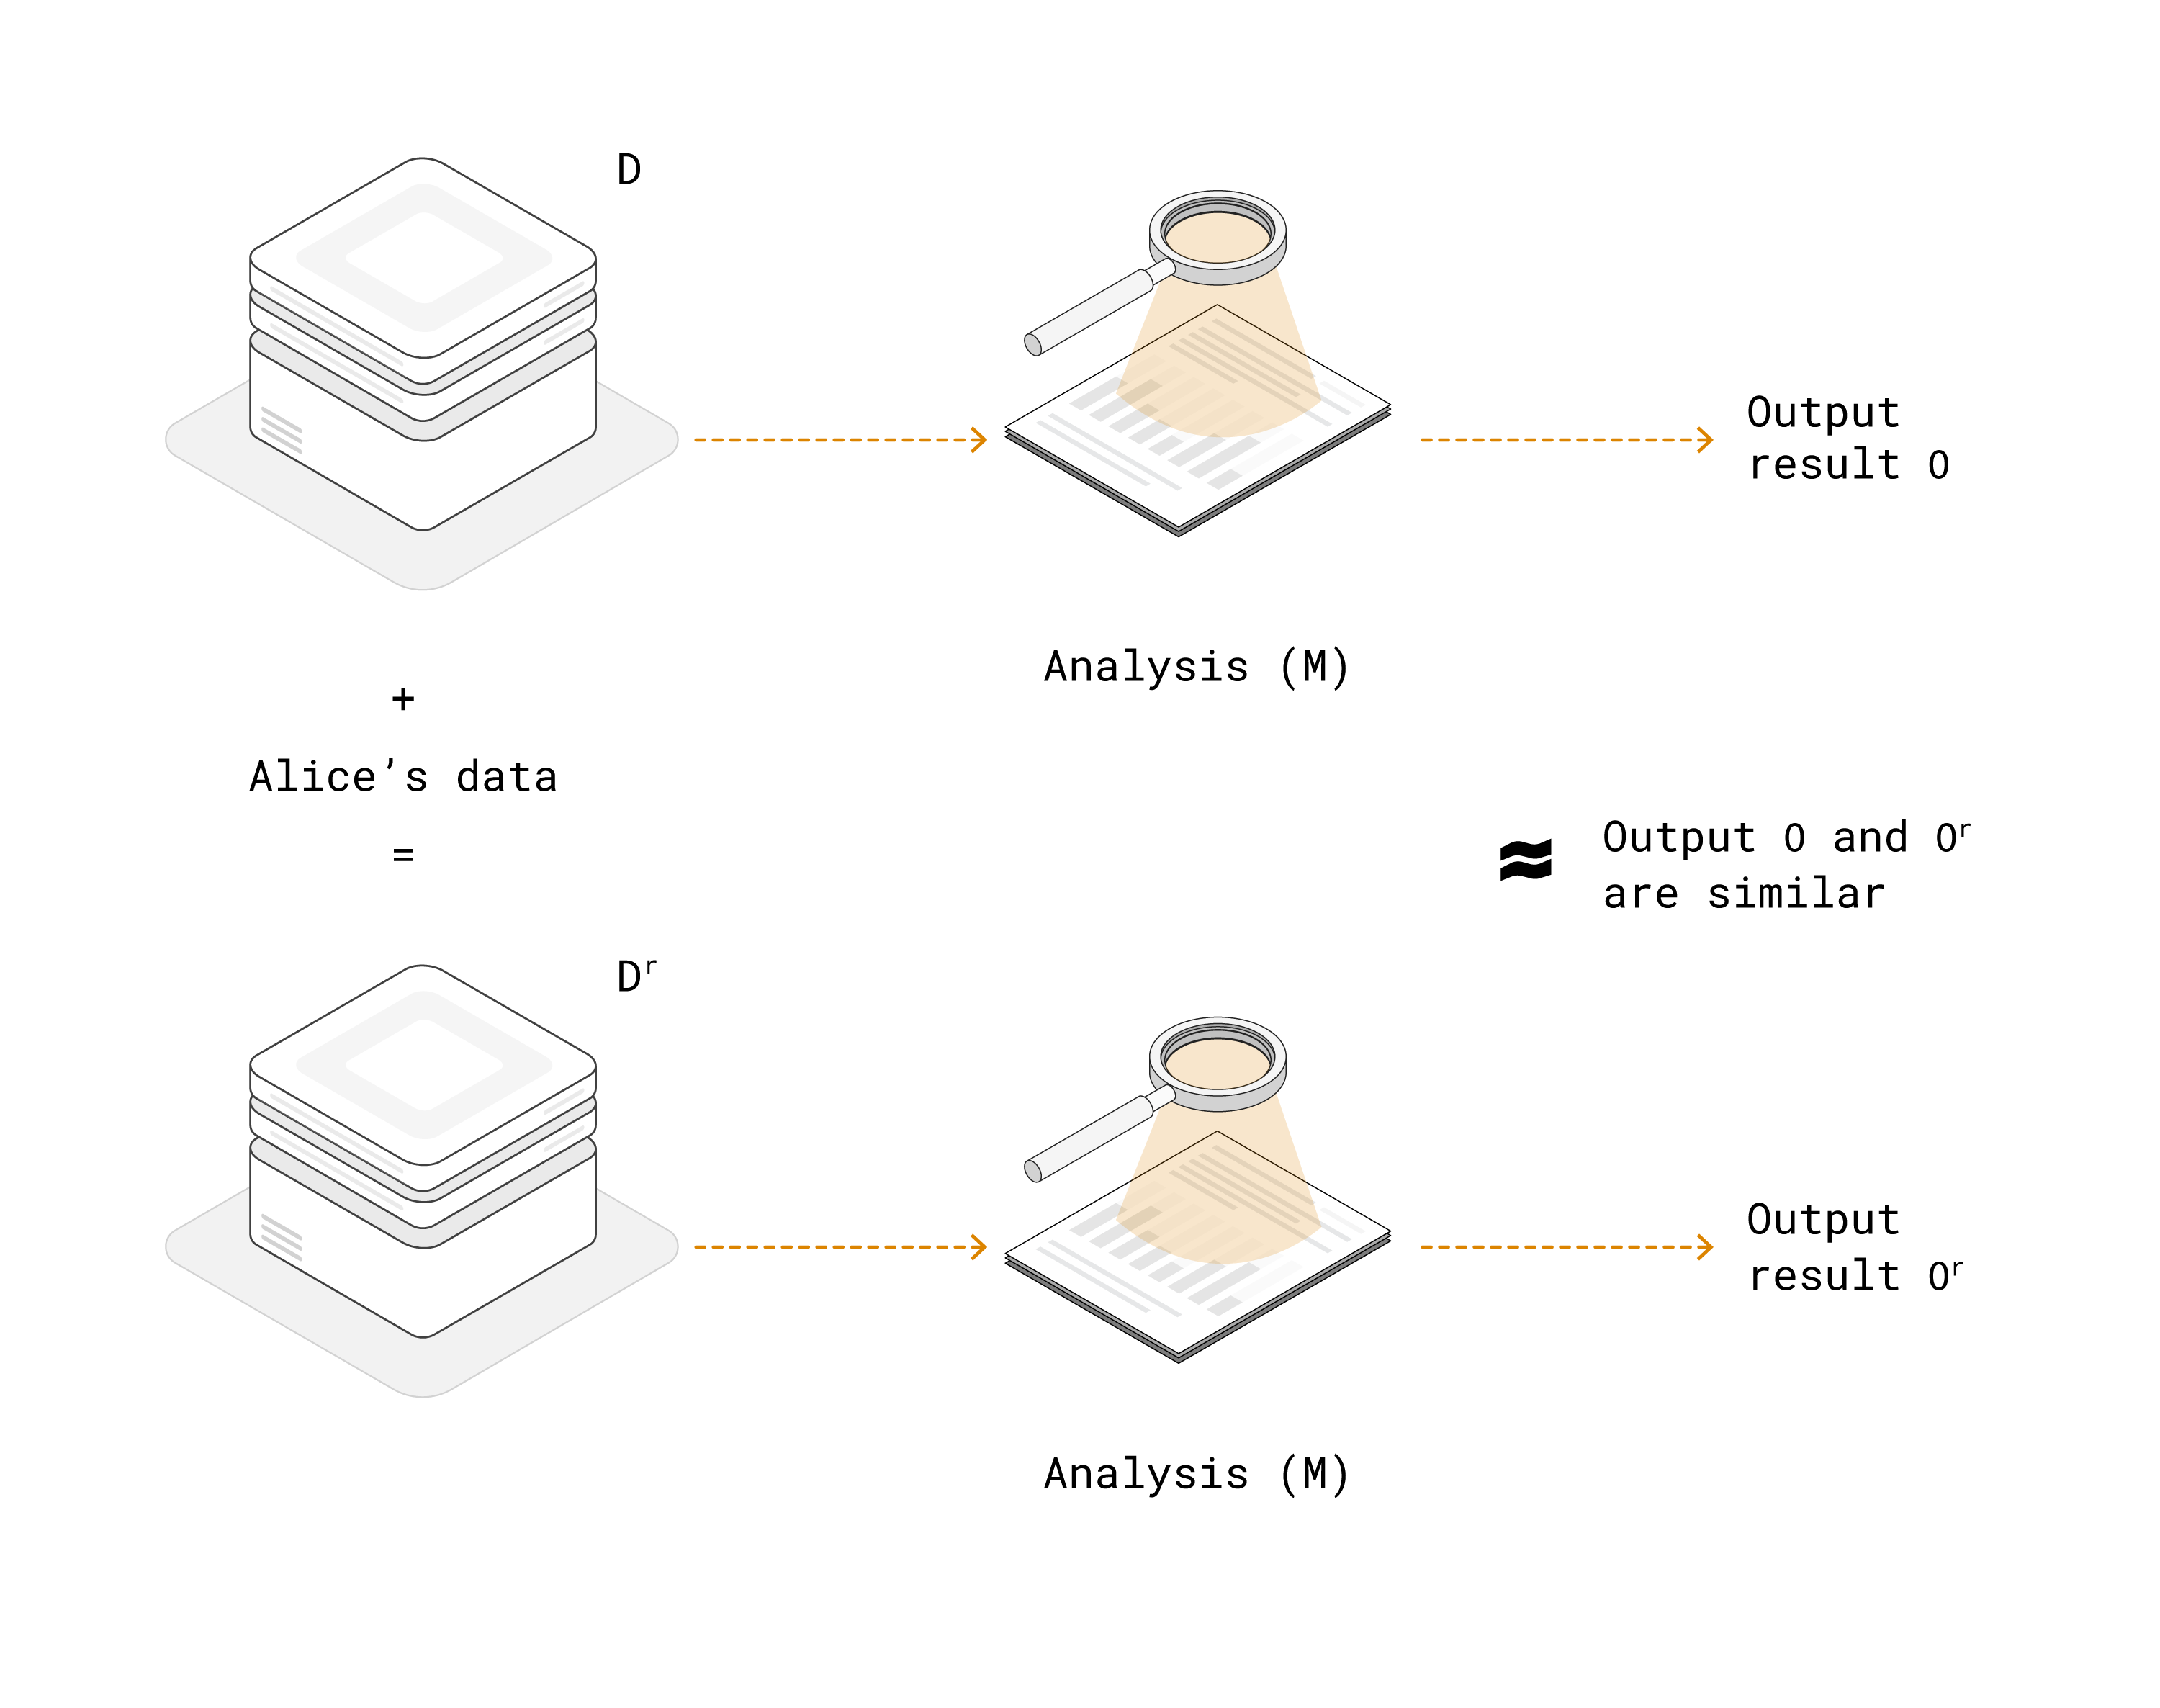
DP Intro
One of the most commonly used mechanisms to achieve DP is adding enough noise to the output of the analysis to mask the contribution of each individual in the data while preserving the overall accuracy of the analysis.


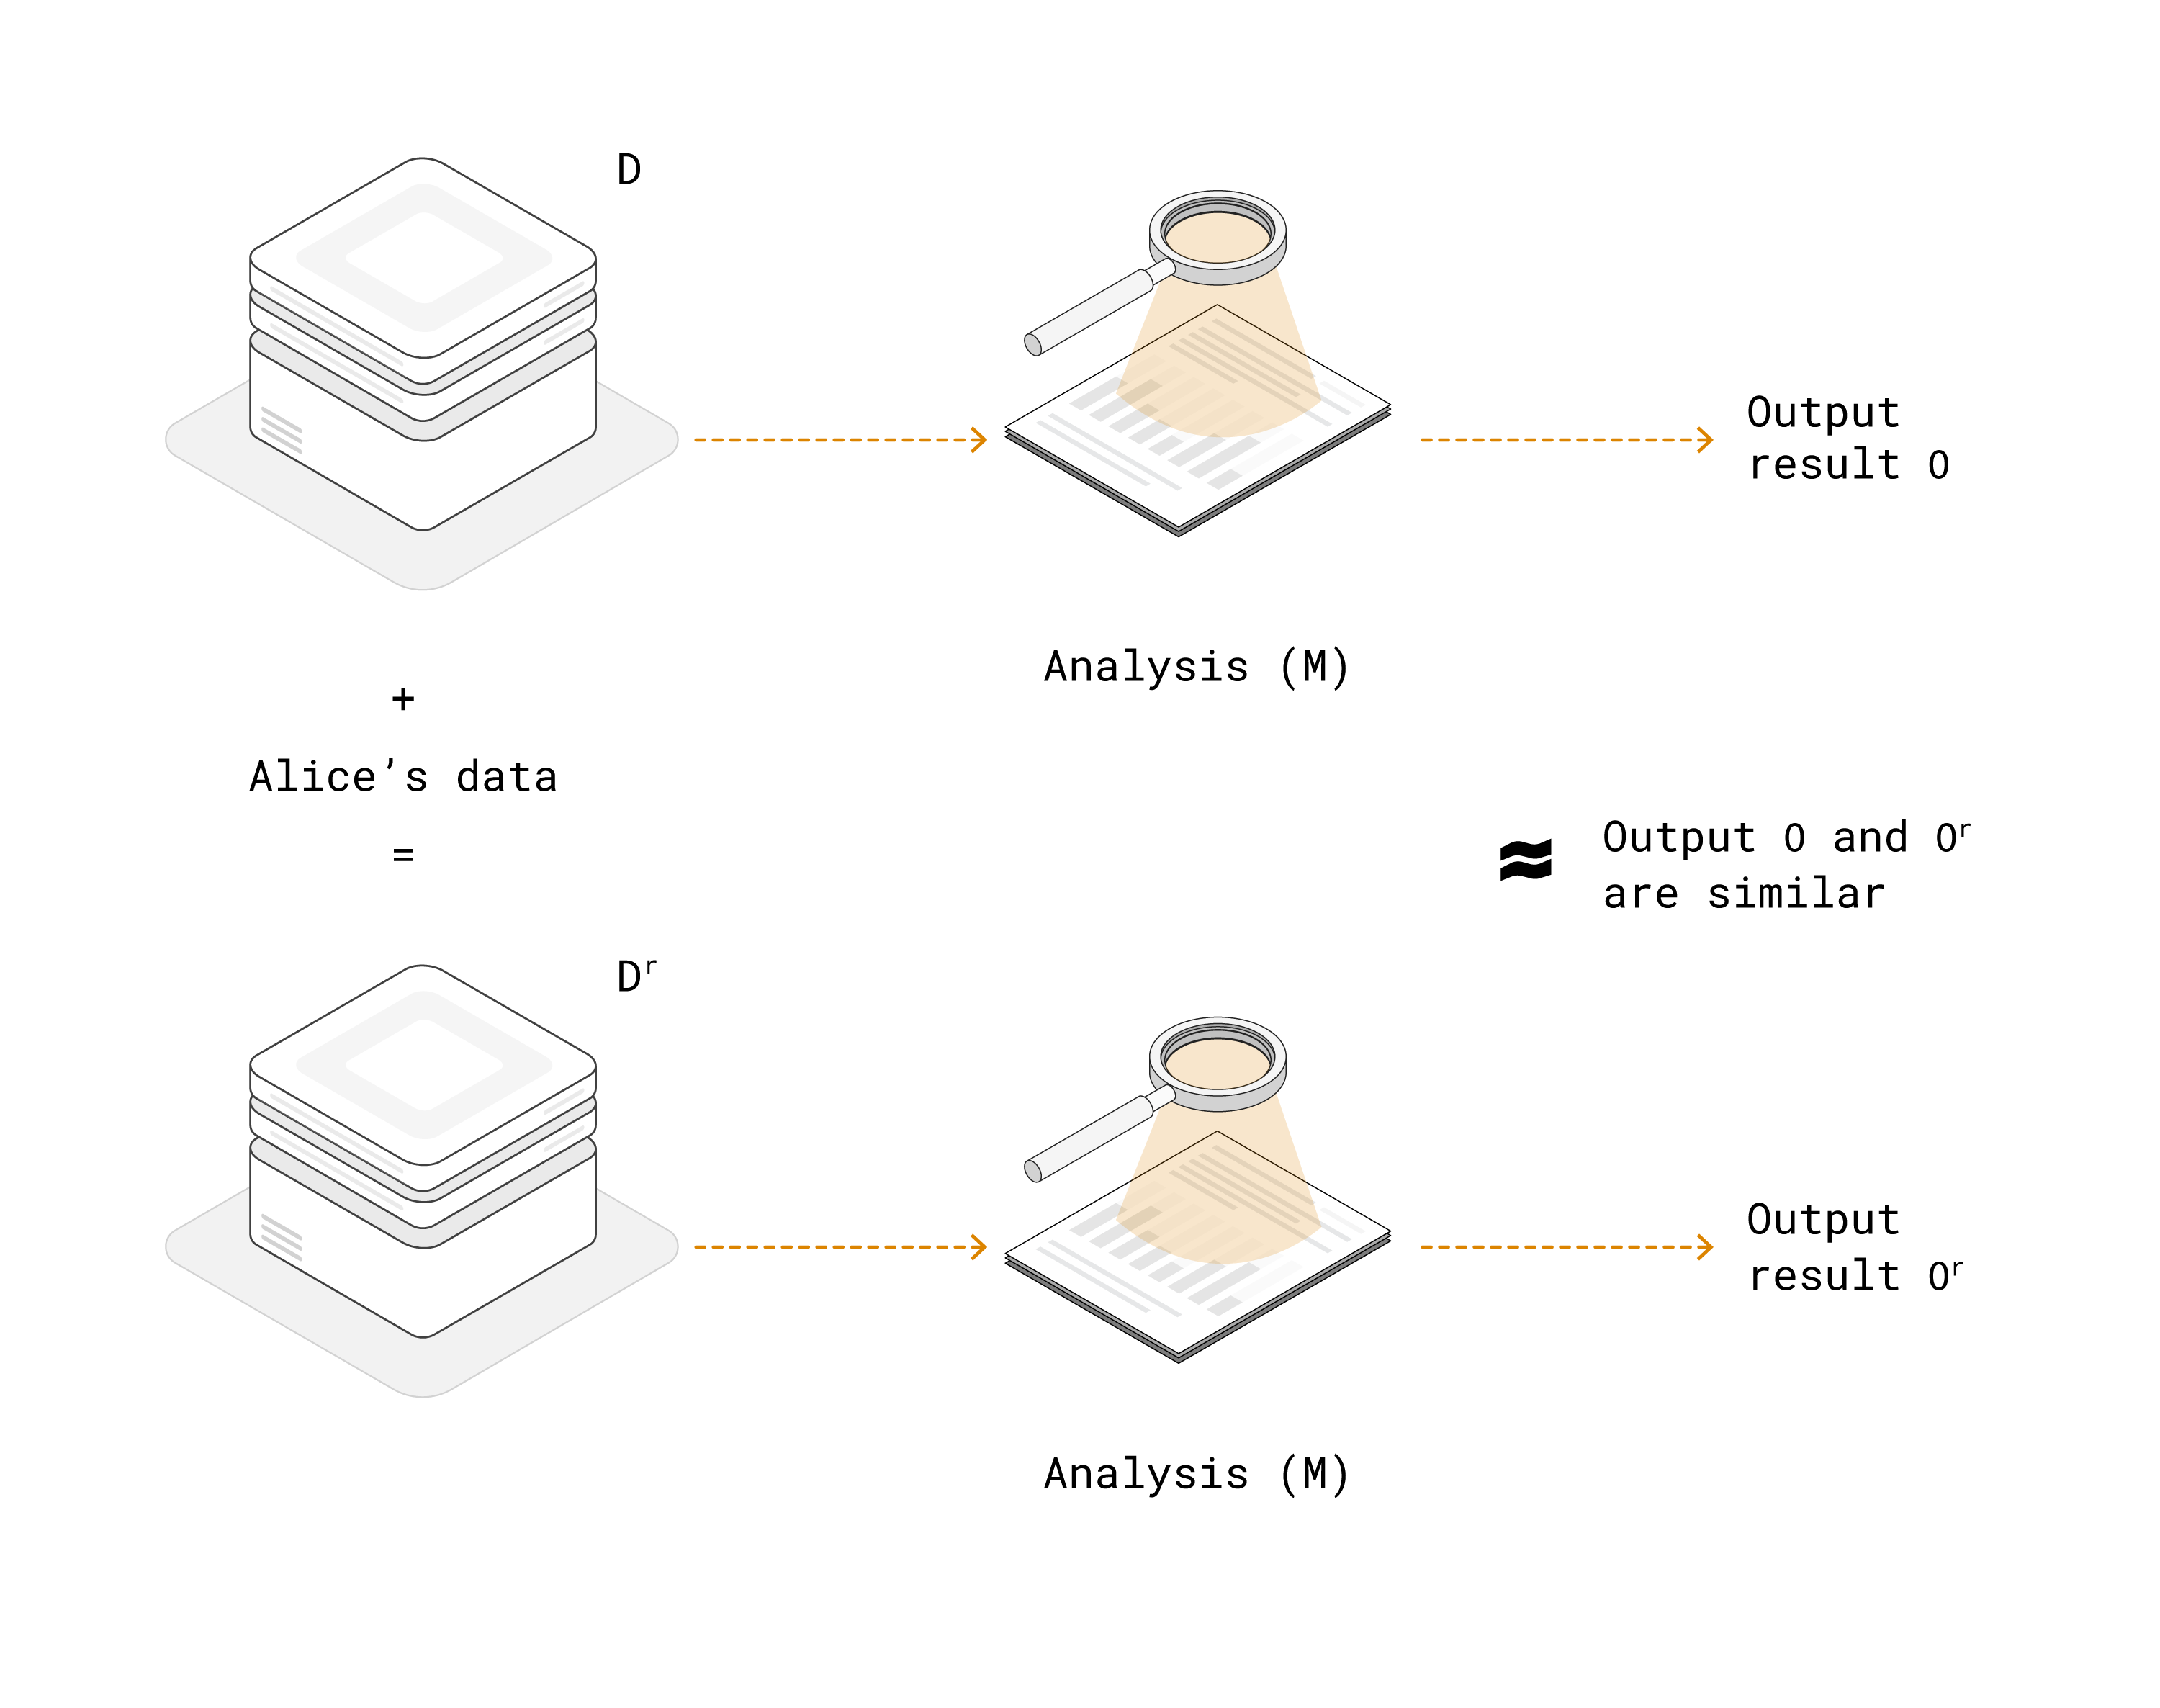

# Differential Privacy

## 1. Definition

**Differential Privacy (DP)** is a mathematical framework used to protect the privacy of individuals whose information appears in a dataset.

The main objective of differential privacy is to ensure that the output of an algorithm does not change significantly when one person's data is added to or removed from the dataset.

In simple words:

> An observer should not be able to confidently determine whether a particular person's data was used by examining the algorithm's output.

Differential privacy does not hide the complete dataset. Instead, it limits how much information the algorithm can reveal about any one protected record or user.

---

## 2. Neighboring Datasets

Differential privacy compares two datasets called **neighboring datasets**.

Let:

$$
D = \{x_1,x_2,\ldots,x_n\}
$$

and:

$$
D' = \{x_1,x_2,\ldots,x_{n-1}\}.
$$

The datasets $D$ and $D'$ are neighbors because they differ by one protected record.

Depending on the privacy definition, neighboring datasets may differ by:

- one individual record;
- all records belonging to one user;
- one device's complete contribution;
- one organization's complete contribution.

The protected entity is called the **privacy unit**.

### Record-level privacy

In record-level privacy, two datasets are neighbors if they differ by one record.

### User-level privacy

In user-level privacy, two datasets are neighbors if they differ by all records belonging to one user.

User-level privacy is normally stronger when each person contributes multiple records.

---

## 3. Formal Definition

A randomized algorithm $M$ satisfies $(\varepsilon,\delta)$-differential privacy if, for every pair of neighboring datasets $D$ and $D'$ and every possible set of outputs $S$:

$$
\Pr[M(D)\in S]
\leq
e^{\varepsilon}\Pr[M(D')\in S]+\delta.
$$

The symbols represent:

- $M$: a randomized algorithm or privacy mechanism;
- $D$ and $D'$: neighboring datasets;
- $S$: any possible set of algorithm outputs;
- $\Pr$: probability;
- $\varepsilon$: the privacy-loss parameter;
- $\delta$: a small probability of exceeding the main privacy guarantee.

The definition requires the algorithm to produce similar output distributions for both neighboring datasets.

Therefore, the presence or absence of one protected person should not have a large effect on the result.

---

## 4. Understanding Epsilon

The value $\varepsilon$, pronounced **epsilon**, controls the strength of the privacy guarantee.

A smaller value of $\varepsilon$ generally means stronger privacy:

$$
\text{Smaller }\varepsilon
\Longrightarrow
\text{stronger privacy}.
$$

A larger value generally permits more information leakage:

$$
\text{Larger }\varepsilon
\Longrightarrow
\text{weaker privacy}.
$$

For example:

- $\varepsilon = 0.1$ represents a relatively strong privacy constraint;
- $\varepsilon = 1$ provides stronger privacy than $\varepsilon = 8$;
- $\varepsilon = 8$ permits a larger difference between neighboring output distributions;
- $\varepsilon = \infty$ effectively represents the absence of a DP guarantee.

However, epsilon must not be interpreted alone. Its meaning also depends on:

- the privacy unit;
- the value of $\delta$;
- the sampling procedure;
- the number of training steps;
- the threat model;
- whether multiple models are released.

---

## 5. Understanding Delta

The value $\delta$ represents a small probability that the stronger differential-privacy bound may not hold.

It should normally be selected to be very small relative to the number of protected individuals.

The guarantee is often written as:

$$
(\varepsilon,\delta)\text{-DP}.
$$

When $\delta=0$, the mechanism provides **pure differential privacy**:

$$
\Pr[M(D)\in S]
\leq
e^\varepsilon\Pr[M(D')\in S].
$$

When $\delta>0$, the mechanism provides **approximate differential privacy**.

Approximate DP is commonly used in deep learning because mechanisms based on Gaussian noise naturally provide $(\varepsilon,\delta)$-DP.

---

## 6. Why Randomness Is Required

If an algorithm always returns the exact answer, one person's contribution might be detectable.

Suppose a medical dataset contains the following values:

$$
D=\{10,20,30,40\}.
$$

The exact sum is:

$$
f(D)=100.
$$

If one record is removed:

$$
D'=\{10,20,30\},
$$

then:

$$
f(D')=60.
$$

The large difference between $100$ and $60$ reveals considerable information about the removed record.

A differentially private mechanism adds controlled random noise:

$$
M(D)=f(D)+Z,
$$

where $Z$ is a random-noise value.

For example, the mechanism might return:

$$
M(D)=103.4.
$$

Running the same mechanism again may produce:

$$
M(D)=97.8.
$$

Because the output is randomized, an observer cannot directly determine the exact contribution of one person.

The noise must be carefully calibrated. Arbitrary noise does not automatically provide differential privacy.

---

## 7. Sensitivity

**Sensitivity** measures how much a calculation can change when one privacy unit is added, removed, or replaced.

For a function $f$, its global sensitivity is:

$$
\Delta f
=
\max_{D\sim D'}
\left\lVert f(D)-f(D')\right\rVert,
$$

where:

$$
D\sim D'
$$

means that $D$ and $D'$ are neighboring datasets.

A function with high sensitivity requires more noise. A function with low sensitivity generally requires less noise.

### Example: counting query

Consider a function that counts how many people satisfy a condition.

Adding or removing one person can change the count by at most one. Therefore:

$$
\Delta f=1.
$$

### Example: unbounded sum

If individual values have no maximum limit, one person could change the sum by an arbitrarily large amount.

The sensitivity would be unbounded. Values must therefore be clipped or restricted before applying a DP mechanism.

---

## 8. Laplace Mechanism

The Laplace mechanism is commonly used for numerical queries under pure differential privacy.

It is defined as:

$$
M(D)
=
f(D)
+
\operatorname{Lap}
\left(
\frac{\Delta f}{\varepsilon}
\right).
$$

Here:

- $f(D)$ is the original calculation;
- $\Delta f$ is its sensitivity;
- $\varepsilon$ is the privacy budget;
- $\operatorname{Lap}$ represents Laplace-distributed noise.

The noise scale is:

$$
b=\frac{\Delta f}{\varepsilon}.
$$

Therefore:

$$
\text{Smaller }\varepsilon
\Longrightarrow
\text{more noise}
\Longrightarrow
\text{stronger privacy}.
$$

---

## 9. Gaussian Mechanism

The Gaussian mechanism adds noise from a normal distribution:

$$
M(D)=f(D)+\mathcal{N}(0,\sigma^2).
$$

More generally:

$$
M(D)
=
f(D)
+
\mathcal{N}
\left(
0,\sigma^2\Delta f^2 I
\right).
$$

Here:

- $\mathcal{N}$ represents the Gaussian distribution;
- $\sigma$ is the noise multiplier;
- $\Delta f$ is sensitivity;
- $I$ is the identity matrix.

The Gaussian mechanism is commonly used in machine learning and normally provides approximate $(\varepsilon,\delta)$-differential privacy.

---

## 10. Differential Privacy in Machine Learning

In machine learning, a model is trained by repeatedly calculating gradients and updating its parameters.

A normal training update can be represented as:

$$
\theta_{t+1}
=
\theta_t-\eta g_t,
$$

where:

- $\theta_t$ represents the model parameters at step $t$;
- $\eta$ is the learning rate;
- $g_t$ is the training gradient.

Individual gradients may contain information about individual training examples.

Differentially private training limits the effect of each protected unit and adds noise before updating the model.

---

## 11. Differentially Private SGD

**Differentially Private Stochastic Gradient Descent**, or **DP-SGD**, is a common algorithm for training neural networks with differential privacy.

DP-SGD has three main operations:

1. Calculate individual gradients.
2. Clip every gradient.
3. Add calibrated noise to the aggregated gradient.

---

## 12. Per-Example Gradients

For each example $x_i$ in a batch, DP-SGD calculates an individual gradient:

$$
g_i
=
\nabla_\theta
\mathcal{L}(\theta,x_i),
$$

where:

- $\mathcal{L}$ is the loss function;
- $\theta$ represents model parameters;
- $x_i$ is one training example;
- $g_i$ is the example's gradient.

Without protection, one example could produce an extremely large gradient and strongly influence the model.

---

## 13. Gradient Clipping

Gradient clipping limits the maximum influence of each training example.

Each gradient is clipped to a maximum norm $C$:

$$
\bar{g}_i
=
g_i
\cdot
\min
\left(
1,
\frac{C}{\lVert g_i\rVert_2}
\right).
$$

Here:

- $g_i$ is the original gradient;
- $\bar{g}_i$ is the clipped gradient;
- $C$ is the clipping norm;
- $\lVert g_i\rVert_2$ is the gradient's Euclidean norm.

If:

$$
\lVert g_i\rVert_2\leq C,
$$

the gradient remains unchanged.

If:

$$
\lVert g_i\rVert_2>C,
$$

the gradient is reduced so that:

$$
\lVert\bar{g}_i\rVert_2=C.
$$

Clipping bounds sensitivity, but clipping alone does not provide complete differential privacy.

---

## 14. Adding Noise to Gradients

After clipping, the gradients are aggregated and Gaussian noise is added:

$$
\tilde{g}
=
\frac{1}{B}
\left[
\sum_{i=1}^{B}\bar{g}_i
+
\mathcal{N}
\left(
0,\sigma^2C^2I
\right)
\right],
$$

where:

- $B$ is the batch size;
- $C$ is the clipping norm;
- $\sigma$ is the noise multiplier;
- $\tilde{g}$ is the private gradient.

The model is updated using:

$$
\theta_{t+1}
=
\theta_t-\eta\tilde{g}.
$$

Clipping limits each example's influence, while noise hides that limited influence.

Both operations are required:

$$
\text{Clipping}+\text{calibrated noise}
\Longrightarrow
\text{differentially private training}.
$$

---

## 15. Privacy Accounting

Training performs many private updates. Every update consumes part of the privacy budget.

A **privacy accountant** tracks the accumulated privacy loss across all training steps.

The final privacy guarantee depends on:

- sampling rate;
- number of training steps;
- noise multiplier;
- clipping norm;
- value of $\delta$;
- composition method.

The sampling rate is approximately:

$$
q=\frac{B}{N},
$$

where:

- $B$ is the batch size;
- $N$ is the dataset size.

A privacy accountant calculates:

$$
\varepsilon_{\mathrm{total}}
=
\operatorname{Accountant}(q,\sigma,T,\delta),
$$

where $T$ is the total number of training steps.

Privacy loss increases as more private operations are performed.

---

## 16. Composition

**Composition** describes how privacy loss accumulates when several differentially private operations are performed.

If several mechanisms are applied to the same protected data, their privacy costs must be considered together.

A simplified bound is:

$$
\varepsilon_{\mathrm{total}}
\leq
\sum_{t=1}^{T}\varepsilon_t,
$$

and:

$$
\delta_{\mathrm{total}}
\leq
\sum_{t=1}^{T}\delta_t.
$$

Modern privacy accountants can provide tighter bounds than this simple sum.

---

## 17. Privacy Amplification by Sampling

During each training step, only a randomly selected subset of the dataset may be used.

Because one person is not included in every step, random sampling can strengthen the overall privacy guarantee.

This effect is called **privacy amplification by sampling**.

However, the guarantee depends on using the sampling procedure assumed by the privacy accountant.

---

## 18. Record-Level and User-Level DP

### Record-level DP

Each record is protected separately.

Suppose one user contributes $100$ messages. Record-level DP protects each message individually, but it may not adequately protect the user's combined information.

### User-level DP

All records belonging to one user are treated as one privacy unit.

Let the data belonging to user $u$ be:

$$
D_u=\{x_{u,1},x_{u,2},\ldots,x_{u,m}\}.
$$

User-level neighboring datasets differ by the complete set $D_u$.

This means the privacy guarantee protects the presence or absence of the user's entire contribution.

User-level DP is normally more meaningful for systems where each person contributes multiple records.

---

## 19. Privacy and Utility Trade-Off

Differential privacy creates a trade-off between privacy and model performance.

Stronger privacy generally requires more noise:

$$
\text{stronger privacy}
\Longrightarrow
\text{more noise}
\Longrightarrow
\text{possible utility reduction}.
$$

We can represent the goal as:

$$
\max \operatorname{Utility}(M)
\quad
\text{subject to}
\quad
M\text{ satisfying }(\varepsilon,\delta)\text{-DP}.
$$

If too little noise is added, privacy may be weak.

If too much noise is added, model accuracy may become unacceptable.

The objective is to find a useful privacy--utility balance.

---

## 20. Privacy Attacks Addressed by DP

Differential privacy can help protect against several attacks.

### Membership inference

An attacker tries to determine whether a record was included in training.

DP limits the difference between models trained with and without that record.

### Training-data extraction

An attacker tries to make the model reproduce specific training information.

DP limits the influence of each protected training unit and can reduce extraction risk.

### Data-memorization leakage

A model memorizes and reveals specific training information.

Differentially private training discourages excessive dependence on individual examples.

### Model inversion

An attacker attempts to reconstruct sensitive characteristics of training inputs.

DP can reduce information about individual records, although practical protection depends on the privacy unit and implementation.

---

## 21. What Differential Privacy Does Not Do

Differential privacy does not automatically:

- encrypt the dataset;
- prevent unauthorized database access;
- protect compromised credentials;
- guarantee model accuracy;
- remove bias;
- stop data poisoning;
- protect information intentionally included in the model input;
- correct an incorrectly chosen privacy unit;
- guarantee privacy if the implementation is incorrect.

DP must be combined with other protections, such as:

- access control;
- encryption;
- data minimization;
- secure aggregation;
- secure software engineering;
- privacy auditing;
- monitoring.

---

## 22. Example

Suppose a hospital trains a model using patient records.

The privacy objective is:

> An attacker should not be able to determine whether a particular patient's information was used for training.

The hospital trains the model using DP-SGD:

1. Each patient's gradient is calculated.
2. Each gradient is clipped.
3. Gaussian noise is added.
4. A privacy accountant tracks the total privacy cost.
5. The final model is released with a reported guarantee.

For example:

$$
\varepsilon=3,
\qquad
\delta=10^{-6}.
$$

The guarantee must also state whether the protected unit is:

- one medical record; or
- one patient's complete collection of records.

Without this information, the reported values are incomplete.

---

## 23. Advantages

The major advantages of differential privacy are:

- It provides a mathematical privacy guarantee.
- It is robust against attackers with additional background knowledge.
- The guarantee continues to apply after the output is released.
- It can protect statistical analyses and machine-learning models.
- Privacy loss can be measured using a privacy accountant.
- It provides protection against broad classes of inference attacks.

---

## 24. Limitations

The major limitations are:

- Noise may reduce model accuracy.
- DP training can increase memory and computational cost.
- Selecting a suitable privacy budget is difficult.
- User-level DP is more challenging than record-level DP.
- Incorrect clipping or accounting can invalidate the guarantee.
- Releasing several models consumes additional privacy budget.
- Rare classes may experience larger utility degradation.
- DP does not replace traditional security controls.

---

## 25. Summary

Differential privacy protects individuals by making the output of an algorithm relatively insensitive to the inclusion or exclusion of one protected privacy unit.

Its formal definition is:

$$
\Pr[M(D)\in S]
\leq
e^\varepsilon\Pr[M(D')\in S]+\delta.
$$

In machine learning, differential privacy is commonly implemented using DP-SGD:

$$
\text{Per-example gradients}
\rightarrow
\text{gradient clipping}
\rightarrow
\text{noise addition}
\rightarrow
\text{privacy accounting}.
$$

The main principle is:

> A model should learn useful patterns about a population without revealing too much information about any one protected person.
```


# Differential Privacy in Machine Learning

Differential Privacy (DP) can be used in machine learning to protect sensitive training information.

A differentially private machine-learning algorithm is designed so that the presence or absence of one protected record or user does not significantly change the distribution of the trained model.

The main objective is:

> The model should learn general patterns from the dataset without learning too much information about any particular person.

A differentially private training algorithm can be represented as:

$$
M(D)\rightarrow\theta,
$$

where:

- $D$ is the training dataset;
- $M$ is the randomized training algorithm;
- $\theta$ represents the trained model parameters.

For two neighboring datasets $D$ and $D'$, the training algorithm satisfies $(\varepsilon,\delta)$-differential privacy if:

$$
\Pr[M(D)\in S]
\leq
e^\varepsilon\Pr[M(D')\in S]+\delta.
$$

The datasets may differ by one record or by all the records belonging to one user, depending on the selected privacy unit.

---

## Approaches for Applying DP in Machine Learning

Differential privacy can be applied at different stages of the machine-learning process.

The principal approaches are:

1. Input perturbation
2. Label perturbation
3. Objective perturbation
4. Gradient perturbation
5. Parameter perturbation
6. Output perturbation

---

## 1. Input Perturbation

Input perturbation adds noise to the features before model training.

Suppose a training example is:

$$
x_i\in\mathbb{R}^d.
$$

The private version may be created as:

$$
\tilde{x}_i=x_i+z_i,
$$

where:

$$
z_i\sim\mathcal{N}(0,\sigma^2I).
$$

The model is trained using $\tilde{x}_i$ instead of the original input $x_i$.

### Advantages

- The training algorithm may remain unchanged.
- Raw features are transformed before training.
- It can be useful in distributed or local privacy settings.

### Limitations

- Noise may significantly reduce data quality.
- High-dimensional data may require substantial noise.
- Arbitrary noise does not automatically provide differential privacy.
- Sensitivity and the neighboring-dataset definition must still be established.

---

## 2. Label Perturbation

Label perturbation changes training labels using a randomized mechanism.

For example, in binary classification:

$$
y_i\in\{0,1\}.
$$

A randomized-response mechanism may retain the original label with probability $p$ and change it with probability $1-p$:

$$
\tilde{y}_i=
\begin{cases}
y_i, & \text{with probability }p,\\
1-y_i, & \text{with probability }1-p.
\end{cases}
$$

The model is then trained using the randomized labels $\tilde{y}_i$.

### Advantages

- It can protect sensitive labels.
- It may be useful when labels contain private information.

### Limitations

- Incorrect labels can reduce model accuracy.
- The privacy guarantee depends on the randomization probability.
- It does not necessarily protect all information contained in the features.

---

## 3. Objective Perturbation

Objective perturbation adds randomness to the optimization objective.

A standard learning objective can be written as:

$$
\theta^*
=
\arg\min_\theta
\left[
\frac{1}{N}
\sum_{i=1}^{N}
\mathcal{L}(\theta,x_i,y_i)
+
\lambda R(\theta)
\right],
$$

where:

- $\mathcal{L}$ is the loss function;
- $R(\theta)$ is a regularization function;
- $\lambda$ controls regularization.

A perturbed objective may include a random vector $b$:

$$
\theta_{\mathrm{private}}^*
=
\arg\min_\theta
\left[
\frac{1}{N}
\sum_{i=1}^{N}
\mathcal{L}(\theta,x_i,y_i)
+
\lambda R(\theta)
+
\frac{1}{N}b^\top\theta
\right].
$$

Objective perturbation is most suitable for certain convex optimization problems. Applying it directly to large non-convex neural networks is more difficult.

---

## 4. Gradient Perturbation

Gradient perturbation adds noise during model training.

The most common example is Differentially Private Stochastic Gradient Descent, or DP-SGD.

For each training example, the algorithm calculates:

$$
g_i
=
\nabla_\theta\mathcal{L}(\theta,x_i,y_i).
$$

The gradient is clipped:

$$
\bar{g}_i
=
g_i
\min
\left(
1,
\frac{C}{\lVert g_i\rVert_2}
\right).
$$

The clipped gradients are aggregated and Gaussian noise is added:

$$
\tilde{g}
=
\frac{1}{B}
\left[
\sum_{i=1}^{B}\bar{g}_i
+
\mathcal{N}(0,\sigma^2C^2I)
\right].
$$

The model is updated using:

$$
\theta_{t+1}
=
\theta_t-\eta\tilde{g}.
$$

Gradient perturbation is commonly used for private neural-network training.

---

## 5. Parameter Perturbation

Parameter perturbation adds noise directly to the trained model parameters.

If the original parameters are:

$$
\theta,
$$

the released parameters may be:

$$
\tilde{\theta}
=
\theta+\mathcal{N}(0,\sigma^2I).
$$

To obtain a formal DP guarantee, the sensitivity of the learned parameters must be bounded.

Simply adding arbitrary noise to model parameters does not automatically provide differential privacy.

---

## 6. Output Perturbation

Output perturbation adds noise to the final result of an algorithm.

For a model output $f_\theta(x)$:

$$
\tilde{y}
=
f_\theta(x)+z,
$$

where $z$ is calibrated random noise.

Output perturbation may protect:

- released statistics;
- model predictions;
- trained parameters;
- query results.

However, prediction noise and training-data privacy are different concepts.

A mechanism that privatizes predictions may protect information in a query, but it does not automatically make the training process differentially private.

---

# Differential Privacy in Federated Learning

## Federated Learning

Federated learning is a data-minimization approach that allows multiple clients to collaboratively train a model without sending their raw data to a central server.

The clients may be:

- mobile devices;
- hospitals;
- banks;
- companies;
- research organizations.

A standard federated-learning round operates as follows:

1. The server selects a group of clients.
2. The server sends the current global model to those clients.
3. Each client trains the model using its local data.
4. Each client sends a model update to the server.
5. The server aggregates the client updates.
6. The global model is updated.
7. The process is repeated.

If the global model at round $t$ is $\theta_t$, client $i$ calculates a local update:

$$
\Delta_i^{(t)}
=
\theta_i^{(t)}-\theta_t.
$$

The server may aggregate the updates using:

$$
\Delta^{(t)}
=
\frac{1}{m}
\sum_{i=1}^{m}
\Delta_i^{(t)},
$$

where $m$ is the number of participating clients.

The global model is then updated:

$$
\theta_{t+1}
=
\theta_t+\Delta^{(t)}.
$$

---

## Privacy Risks in Federated Learning

Federated learning keeps raw data on client devices, but this does not automatically provide a formal privacy guarantee.

Client model updates can leak information about local data.

Possible attacks include:

### Membership-Inference Attack

The attacker attempts to determine whether a particular record or user participated in training.

### Property-Inference Attack

The attacker attempts to infer a general property of a client's private dataset.

### Model-Inversion Attack

The attacker attempts to reconstruct sensitive characteristics of local training data.

### Gradient-Inversion Attack

The attacker attempts to reconstruct local training examples from gradients or model updates.

### User-Participation Inference

The attacker attempts to determine whether a particular client participated in a training round.

Differential privacy can be combined with federated learning to limit such leakage.

---

# Differential-Privacy Models in Federated Learning

Based on where noise is added, DP in federated learning can be divided into two main approaches:

1. Central differential privacy
2. Local differential privacy

These approaches make different trust assumptions and may protect different privacy units.

---

# Central Differential Privacy

In central DP, the server or a trusted aggregation service applies the differential-privacy mechanism to the combined client update.

Central DP is not automatically the same as user-level DP.

It becomes user-level DP when:

- one complete client contribution is treated as one privacy unit;
- each client's update is bounded;
- noise is calibrated to the user-level sensitivity;
- privacy is composed across rounds.

The central-DP process is:

1. Sample clients.
2. Perform local training.
3. Clip each client update.
4. Aggregate the clipped updates.
5. Add calibrated noise.
6. Update the global model.
7. Track privacy loss.

---

## Client-Update Clipping

Let the update from client $i$ be:

$$
\Delta_i.
$$

The update is clipped to a maximum norm $S$:

$$
\bar{\Delta}_i
=
\Delta_i
\min
\left(
1,
\frac{S}{\lVert\Delta_i\rVert_2}
\right).
$$

Here:

- $\Delta_i$ is the original client update;
- $\bar{\Delta}_i$ is the clipped update;
- $S$ is the clipping threshold;
- $\lVert\Delta_i\rVert_2$ is the $L_2$ norm of the update.

After clipping:

$$
\lVert\bar{\Delta}_i\rVert_2\leq S.
$$

Clipping ensures that no single client can have an arbitrarily large influence on the aggregate.

---

## Gaussian Noise in Central DP

For a sum of clipped client updates, a simplified private aggregate is:

$$
\tilde{\Delta}_{\mathrm{sum}}
=
\sum_{i=1}^{m}\bar{\Delta}_i
+
\mathcal{N}
\left(
0,
\sigma^2S^2I
\right).
$$

If the server releases the average update, it can be written as:

$$
\tilde{\Delta}_{\mathrm{avg}}
=
\frac{1}{m}
\left[
\sum_{i=1}^{m}\bar{\Delta}_i
+
\mathcal{N}
\left(
0,
\sigma^2S^2I
\right)
\right].
$$

Equivalently:

$$
\tilde{\Delta}_{\mathrm{avg}}
=
\frac{1}{m}
\sum_{i=1}^{m}\bar{\Delta}_i
+
\mathcal{N}
\left(
0,
\frac{\sigma^2S^2}{m^2}I
\right).
$$

Therefore, the standard deviation of the noise applied to the average is:

$$
\sigma_{\mathrm{avg}}
=
\frac{\sigma S}{m}.
$$

This equation is a simplified representation. The final $(\varepsilon,\delta)$ guarantee must be calculated using a privacy accountant that considers:

- client-sampling probability;
- adjacency definition;
- number of rounds;
- noise multiplier;
- clipping threshold;
- client participation;
- selected value of $\delta$.

---

## Trust Assumption in Central DP

Ordinary central DP assumes the central privacy mechanism is trusted to:

- receive or compute the aggregate correctly;
- add the required amount of noise;
- avoid releasing individual updates;
- maintain correct privacy accounting.

The server may still see individual updates before aggregation.

To reduce this trust requirement, central DP can be combined with **secure aggregation**.

Secure aggregation allows the server to recover:

$$
\sum_{i=1}^{m}\bar{\Delta}_i
$$

without observing each individual update $\bar{\Delta}_i$.

The server then adds noise to the protected aggregate.

A stronger design may use distributed noise generation so that no single server is solely responsible for adding the required noise.

---

# Fixed Clipping

Fixed clipping uses a predefined clipping threshold $S$ throughout training.

For every client:

$$
\bar{\Delta}_i
=
\Delta_i
\min
\left(
1,
\frac{S}{\lVert\Delta_i\rVert_2}
\right).
$$

### Advantages

- Simple to implement
- Easy to analyze
- Predictable sensitivity
- Compatible with privacy accounting

### Limitations

If $S$ is too small:

- many updates are heavily clipped;
- useful information is lost;
- model utility may decrease.

If $S$ is too large:

- sensitivity becomes larger;
- more noise is required;
- the privacy--utility trade-off may worsen.

---

# Adaptive Clipping

Adaptive clipping changes the clipping threshold during training.

The threshold may be selected using a quantile of the client-update norm distribution.

For example, if the target quantile is $q$, the system attempts to choose $S_t$ such that:

$$
\Pr
\left[
\lVert\Delta_i^{(t)}\rVert_2\leq S_t
\right]
\approx q.
$$

The clipping value changes across rounds:

$$
S_1,S_2,\ldots,S_T.
$$

A simplified update rule may be written as:

$$
S_{t+1}
=
S_t
\exp
\left[
-\eta_c
\left(
\hat{q}_t-q
\right)
\right],
$$

where:

- $\eta_c$ is the clipping learning rate;
- $q$ is the target quantile;
- $\hat{q}_t$ is the privately estimated fraction of updates below $S_t$.

### Advantages

- Adjusts to changing update distributions
- Reduces manual threshold tuning
- May improve model utility
- May avoid excessive clipping

### Limitations

- Estimating the quantile may consume privacy budget.
- Non-private adaptation can leak information.
- The privacy accountant must include the adaptation mechanism.
- It adds implementation complexity.

The clipping threshold must not be adapted using sensitive statistics without accounting for the resulting privacy loss.

---

# Central-DP Federated-Learning Algorithm

A simplified central user-level DP algorithm is:

$$
\boxed{
\text{Sample}
\rightarrow
\text{Local train}
\rightarrow
\text{Clip}
\rightarrow
\text{Securely aggregate}
\rightarrow
\text{Add noise}
\rightarrow
\text{Account}
}
$$

For round $t$:

$$
C_t\leftarrow\operatorname{SampleClients}(q),
$$

$$
\Delta_i^{(t)}
\leftarrow
\operatorname{LocalTrain}(\theta_t,D_i),
$$

$$
\bar{\Delta}_i^{(t)}
=
\Delta_i^{(t)}
\min
\left(
1,
\frac{S}{\lVert\Delta_i^{(t)}\rVert_2}
\right),
$$

$$
A_t
=
\sum_{i\in C_t}
\bar{\Delta}_i^{(t)},
$$

$$
\tilde{A}_t
=
A_t+
\mathcal{N}
\left(
0,\sigma^2S^2I
\right),
$$

and:

$$
\theta_{t+1}
=
\theta_t+
\frac{\tilde{A}_t}{|C_t|}.
$$

The privacy accountant then records the round's contribution to the total privacy loss.

---

# Local Differential Privacy

In local DP, each client applies a privacy mechanism before transmitting information to the server.

The server receives only privatized client information.

A local mechanism $M$ satisfies $(\varepsilon,\delta)$-local differential privacy if, for any two possible client inputs $x$ and $x'$:

$$
\Pr[M(x)\in S]
\leq
e^\varepsilon\Pr[M(x')\in S]+\delta.
$$

Local DP reduces the need to trust the central server with an unprotected update.

However, local DP often requires substantially more noise than central DP, resulting in lower utility for the same numerical privacy parameters.

It is more accurate to say:

> Local DP provides protection under a stronger adversarial model, but usually has a worse privacy--utility trade-off than central DP.

It should not simply be described as always providing “better privacy,” because central and local DP use different trust models and may have different interpretations.

---

## Local Update Perturbation

Each client first clips its update:

$$
\bar{\Delta}_i
=
\Delta_i
\min
\left(
1,
\frac{S}{\lVert\Delta_i\rVert_2}
\right).
$$

The client then adds noise:

$$
\tilde{\Delta}_i
=
\bar{\Delta}_i
+
\mathcal{N}
\left(
0,
\sigma_{\mathrm{local}}^2S^2I
\right).
$$

The client sends $\tilde{\Delta}_i$ to the server.

The server aggregates the privatized updates:

$$
\tilde{\Delta}
=
\frac{1}{m}
\sum_{i=1}^{m}
\tilde{\Delta}_i.
$$

Because every client adds noise separately, the total noise may be much larger than noise added once to the aggregate.

---

## Local DP-SGD

A client may instead perform DP-SGD during local training.

For each local example $x_{i,j}$, client $i$ calculates:

$$
g_{i,j}
=
\nabla_\theta
\mathcal{L}
\left(
\theta,x_{i,j}
\right).
$$

The gradient is clipped:

$$
\bar{g}_{i,j}
=
g_{i,j}
\min
\left(
1,
\frac{C}{\lVert g_{i,j}\rVert_2}
\right).
$$

The client adds noise to the aggregated local gradient:

$$
\tilde{g}_i
=
\frac{1}{B_i}
\left[
\sum_{j=1}^{B_i}
\bar{g}_{i,j}
+
\mathcal{N}
\left(
0,\sigma_i^2C^2I
\right)
\right].
$$

The client uses $\tilde{g}_i$ for local model updates.

---

# Difference Between Local Update Perturbation and Local DP-SGD

These approaches may protect different privacy units.

## Client-update perturbation

The entire client update is clipped and randomized:

$$
\Delta_i
\rightarrow
\bar{\Delta}_i
\rightarrow
\tilde{\Delta}_i.
$$

This can provide client-level or user-level protection when the client's complete contribution is treated as one privacy unit.

## Local DP-SGD

Individual local gradients are clipped and randomized:

$$
g_{i,j}
\rightarrow
\bar{g}_{i,j}
\rightarrow
\tilde{g}_i.
$$

This normally provides record-level protection within the client's dataset unless gradients are grouped and clipped at the user level.

Therefore:

> Adding noise to a complete client update and adding noise to individual local gradients are not automatically equivalent.

The privacy unit, neighboring relation, sensitivity and privacy accountant must be clearly specified.

---

# Central DP and Local DP Comparison

| Property | Central DP | Local DP |
|---|---|---|
| Noise location | Server or trusted aggregation service | Individual client |
| Server sees unprotected update | Possibly, unless secure aggregation is used | No |
| Server trust | Trusted privacy mechanism required | Less trust in the server |
| Typical utility | Better | Lower |
| Required noise | Usually lower | Usually higher |
| Privacy unit | Record or user | Record, update, or user |
| Secure aggregation | Strongly beneficial | Optional but still useful |
| Scalability | Generally more practical | Can require many clients |
| Main risk | Trusted server may fail | Excessive noise may reduce utility |

---

# Differential Privacy with Secure Aggregation

Secure aggregation and differential privacy solve different problems.

## Secure Aggregation

Secure aggregation hides individual client updates from the server.

It protects:

$$
\Delta_i
$$

during aggregation.

However, secure aggregation alone does not prevent the final model from leaking information.

## Differential Privacy

Differential privacy limits what can be learned about a client from the aggregate and the final model.

Together:

$$
\text{Secure aggregation}
+
\text{Differential privacy}
=
\text{protected updates}
+
\text{protected released model}.
$$

Secure aggregation is a cryptographic guarantee, while differential privacy is a statistical guarantee.

---

# Important Implementation Requirements

A valid differentially private federated-learning system must specify:

1. The privacy unit
2. The neighboring-dataset definition
3. The clipping method
4. The clipping threshold
5. The noise mechanism
6. The noise multiplier
7. The client-sampling method
8. The number of training rounds
9. The privacy accountant
10. The values of $\varepsilon$ and $\delta$
11. The server trust assumptions
12. Whether secure aggregation is used
13. How client dropout is handled
14. Which intermediate and final outputs are released

Without these details, it is not possible to evaluate the claimed privacy guarantee.

---

# Summary

Differential privacy can be applied to machine learning at several stages:

$$
\text{Input}
\rightarrow
\text{Labels}
\rightarrow
\text{Objective}
\rightarrow
\text{Gradients}
\rightarrow
\text{Parameters}
\rightarrow
\text{Output}.
$$

In federated learning, the two principal approaches are:

### Central DP

$$
\text{Client updates}
\rightarrow
\text{clipping}
\rightarrow
\text{aggregation}
\rightarrow
\text{server noise}.
$$

### Local DP

$$
\text{Client update}
\rightarrow
\text{client clipping}
\rightarrow
\text{client noise}
\rightarrow
\text{server}.
$$

Central DP normally provides better utility but requires trust in the aggregation mechanism. Local DP reduces this trust requirement but generally introduces more noise.

The strongest practical design often combines:

$$
\boxed{
\text{Federated learning}
+
\text{secure aggregation}
+
\text{user-level differential privacy}
+
\text{privacy accounting}
}
$$
```